In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [62]:
data=pd.read_csv(r'C:\Users\Bhwan\Downloads\Mock_Skincare_Dataset - Data.csv')
data.head()

,Product Name,Brand,Brand Tier,Price (USD),COGS (USD),Days of Inventory,Units in Stock,Views Last Month,Volume Sold Last Month
0,Pure Collagen Cleanser,COSRX,B,36.22,14.83,33,307,3059,185
1,Fresh Snail Mucin Cleanser,Skinfood,A,76.55,45.24,84,234,2365,46
2,Soothing Hyaluronic Acid Emulsion,Tony Moly,A,61.24,30.27,81,466,2579,190
3,Glow Niacinamide Mask,Missha,A,51.91,28.68,45,361,4746,227
4,Hydra Collagen Serum,Skinfood,B,20.92,14.06,47,70,1735,126


In [63]:
data.shape

(100, 9)

In [64]:
data['Profit']=data['Price (USD)']-data['COGS (USD)']
data['Margin %'] = ((data['Price (USD)'] - data['COGS (USD)']) / data['COGS (USD)']) * 100

data.head()

,Product Name,Brand,Brand Tier,Price (USD),COGS (USD),Days of Inventory,Units in Stock,Views Last Month,Volume Sold Last Month,Profit,Margin %
0,Pure Collagen Cleanser,COSRX,B,36.22,14.83,33,307,3059,185,21.39,144.234659
1,Fresh Snail Mucin Cleanser,Skinfood,A,76.55,45.24,84,234,2365,46,31.31,69.208665
2,Soothing Hyaluronic Acid Emulsion,Tony Moly,A,61.24,30.27,81,466,2579,190,30.97,102.312521
3,Glow Niacinamide Mask,Missha,A,51.91,28.68,45,361,4746,227,23.23,80.997211
4,Hydra Collagen Serum,Skinfood,B,20.92,14.06,47,70,1735,126,6.86,48.790896


In [65]:
Brand_per_vol=data.groupby('Brand')['Volume Sold Last Month'].agg('sum').reset_index()
Brand_per_vol.sort_values('Volume Sold Last Month',ascending=False)

,Brand,Volume Sold Last Month
11,Skinfood,2302
9,Missha,2157
14,Tony Moly,2124
10,Neogen,1648
0,Benton,1567
1,COSRX,1556
12,Sulwhasoo,1522
2,Dr. Jart+,1259
6,Innisfree,1124
7,Laneige,1077


In [66]:
Brand_per_vol[Brand_per_vol['Volume Sold Last Month'] < 600]


,Brand,Volume Sold Last Month
4,Hera,501
5,IOPE,590
13,The Face Shop,529


In [67]:
def product_sales(Brand):
    return data[data['Brand']==Brand]

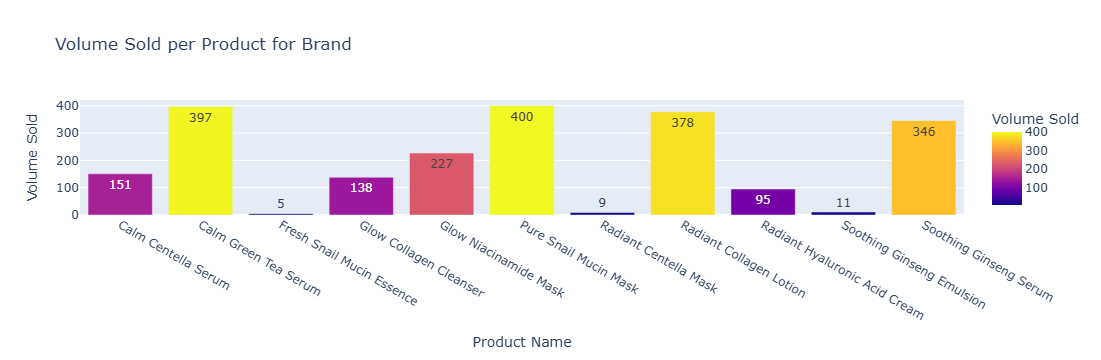

In [69]:
product_counts = product_sales('Missha').groupby('Product Name')['Volume Sold Last Month'].sum().reset_index()
product_counts.columns = ['Product Name', 'Volume Sold']

fig = px.bar(
    product_counts,
    x='Product Name',
    y='Volume Sold',
    color='Volume Sold',
    text='Volume Sold',
    title="Volume Sold per Product for Brand"
)

fig.show()


In [70]:
def recommend_price_change(row):
    if row['Margin %'] < 10:
        return 'Increase Price or Reduce Cost'
    elif row['Margin %'] > 50 and row['Volume Sold Last Month'] < 50:
        return 'Reduce Price to Increase Sales'
    elif 20 <= row['Margin %'] <= 50 and row['Volume Sold Last Month'] > 100:
        return 'Maintain Price'
    elif row['Units in Stock'] > 500 and row['Volume Sold Last Month'] < 30:
        return 'Add Discounts to Clear Stocks'
    
    else:
        return 'To Monitor'


In [71]:
data['Recommendation'] = data.apply(recommend_price_change, axis=1)
data

,Product Name,Brand,Brand Tier,Price (USD),COGS (USD),Days of Inventory,Units in Stock,Views Last Month,Volume Sold Last Month,Profit,Margin %,Recommendation
0,Pure Collagen Cleanser,COSRX,B,36.22,14.83,33,307,3059,185,21.39,144.234659,To Monitor
1,Fresh Snail Mucin Cleanser,Skinfood,A,76.55,45.24,84,234,2365,46,31.31,69.208665,Reduce Price to Increase Sales
2,Soothing Hyaluronic Acid Emulsion,Tony Moly,A,61.24,30.27,81,466,2579,190,30.97,102.312521,To Monitor
3,Glow Niacinamide Mask,Missha,A,51.91,28.68,45,361,4746,227,23.23,80.997211,To Monitor
4,Hydra Collagen Serum,Skinfood,B,20.92,14.06,47,70,1735,126,6.86,48.790896,Maintain Price
...,...,...,...,...,...,...,...,...,...,...,...,...
95,Glow Mugwort Cream,The Face Shop,B,44.57,22.50,25,66,3322,5,22.07,98.088889,Reduce Price to Increase Sales
96,Calm Mugwort Ampoule,The Face Shop,C,46.59,28.78,23,113,1267,377,17.81,61.883252,To Monitor
97,Bright Centella Cream,Skinfood,B,39.93,26.72,85,257,2716,58,13.21,49.438623,To Monitor
98,Glow Centella Lotion,Dr. Jart+,C,11.78,7.85,24,465,1162,378,3.93,50.063694,To Monitor


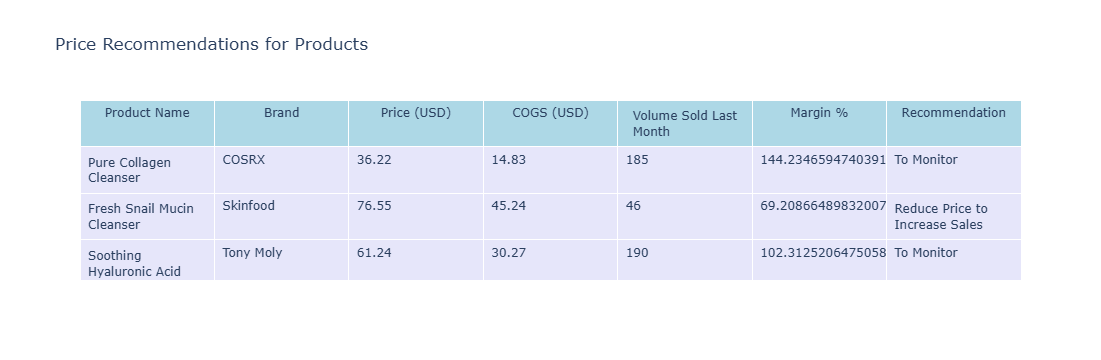

In [72]:
import plotly.graph_objects as go

cols_to_show = ['Product Name', 'Brand', 'Price (USD)', 'COGS (USD)', 'Volume Sold Last Month','Margin %', 'Recommendation']

fig = go.Figure(data=[go.Table(
    header=dict(values=cols_to_show, fill_color='lightblue', align='center'),
    cells=dict(values=[data[col] for col in cols_to_show], fill_color='lavender', align='left'))
])
fig.update_layout(title='Price Recommendations for Products')
fig.show()


In [73]:
# PROMOTIONAL CAMPAIGN

In [74]:
Brand_per_vol = data.groupby('Brand').agg({
    'Profit': 'mean',
    'Volume Sold Last Month': 'sum'
}).reset_index()


In [75]:
Brand_per_vol

,Brand,Profit,Volume Sold Last Month
0,Benton,21.975000,1567
1,COSRX,20.472222,1556
2,Dr. Jart+,22.232000,1259
3,Etude House,20.900000,880
4,Hera,19.223333,501
5,IOPE,18.390000,590
6,Innisfree,17.754000,1124
7,Laneige,18.742000,1077
8,Mamonde,16.796667,851
9,Missha,21.848333,2157


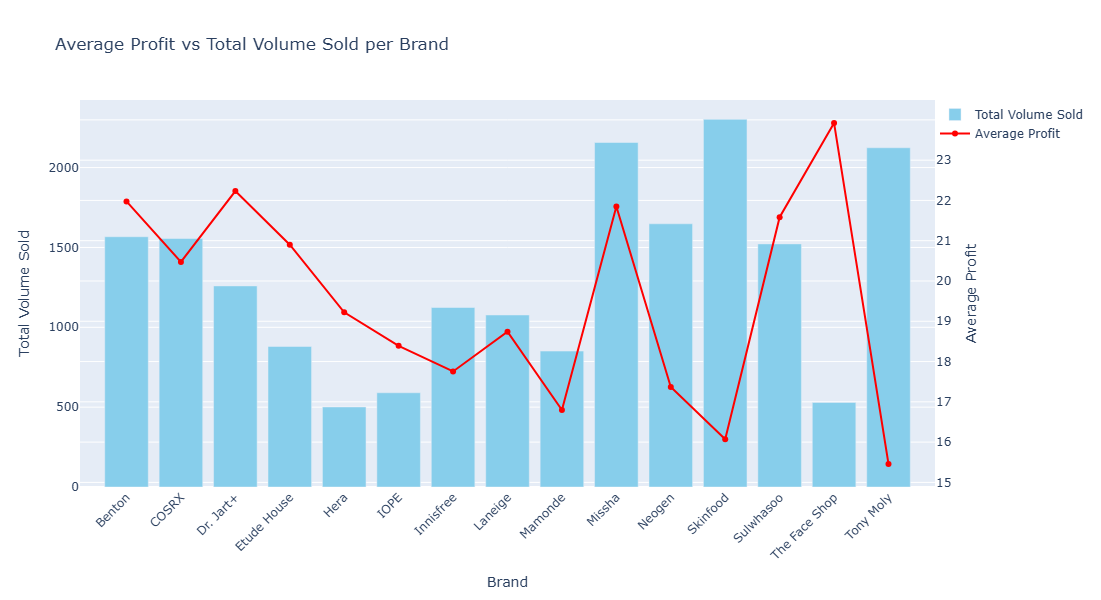

In [76]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(
    x=Brand_per_vol['Brand'],
    y=Brand_per_vol['Volume Sold Last Month'],
    name='Total Volume Sold',
    yaxis='y',
    marker_color='skyblue'
))
fig.add_trace(go.Scatter(
    x=Brand_per_vol['Brand'],
    y=Brand_per_vol['Profit'],
    name='Average Profit',
    yaxis='y2',
    mode='lines+markers',
    line=dict(color='red')
))

fig.update_layout(
    title='Average Profit vs Total Volume Sold per Brand',
    xaxis=dict(title='Brand', tickangle=-45),
    yaxis=dict(title='Total Volume Sold'),
    yaxis2=dict(title='Average Profit', overlaying='y', side='right'),
    width=1100,
    height=600,
    legend=dict(x=1.0, y=1),
 
)

fig.show()


In [77]:
data.head(1)
data.groupby('Brand')['Units in Stock'].agg('sum').reset_index()

,Brand,Units in Stock
0,Benton,2488
1,COSRX,1731
2,Dr. Jart+,1315
3,Etude House,430
4,Hera,552
5,IOPE,931
6,Innisfree,831
7,Laneige,1643
8,Mamonde,1527
9,Missha,2221


In [78]:
data.head(1)

,Product Name,Brand,Brand Tier,Price (USD),COGS (USD),Days of Inventory,Units in Stock,Views Last Month,Volume Sold Last Month,Profit,Margin %,Recommendation
0,Pure Collagen Cleanser,COSRX,B,36.22,14.83,33,307,3059,185,21.39,144.234659,To Monitor


In [79]:
offers=data[(data['Volume Sold Last Month']<100) & (data['Units in Stock']>200)]  # offers
offers['Brand'].value_counts()

Brand
Skinfood     2
Neogen       2
Missha       2
Mamonde      2
Sulwhasoo    1
Benton       1
COSRX        1
Name: count, dtype: int64

In [80]:
brand_wise_views=data.groupby('Brand')['Views Last Month'].mean().reset_index()
brand_wise_views['Views Last Month'].mean()

2583.224326599327

In [81]:
brand_p=data.groupby('Brand')['Profit'].mean().reset_index()
brand_p['Profit'].mean()

19.515974410774408

In [82]:
def Rationale(row):
    if row['Volume Sold Last Month'] < 100 and row['Units in Stock'] > 200:
        return 'Run 10% - 20% offers'
    elif row['Volume Sold Last Month'] < 100 and row['Views Last Month'] < 2400:
        return 'Buy 1 Get 1 Free'
    elif row['Profit'] > 20 and row['Views Last Month'] > 2500 and row['Volume Sold Last Month'] < 100:
        return 'Decrease Profit %'
    else:
        return 'Good'

In [83]:
data['Rationale'] = data.apply(Rationale, axis=1)

data

,Product Name,Brand,Brand Tier,Price (USD),COGS (USD),Days of Inventory,Units in Stock,Views Last Month,Volume Sold Last Month,Profit,Margin %,Recommendation,Rationale
0,Pure Collagen Cleanser,COSRX,B,36.22,14.83,33,307,3059,185,21.39,144.234659,To Monitor,Good
1,Fresh Snail Mucin Cleanser,Skinfood,A,76.55,45.24,84,234,2365,46,31.31,69.208665,Reduce Price to Increase Sales,Run 10% - 20% offers
2,Soothing Hyaluronic Acid Emulsion,Tony Moly,A,61.24,30.27,81,466,2579,190,30.97,102.312521,To Monitor,Good
3,Glow Niacinamide Mask,Missha,A,51.91,28.68,45,361,4746,227,23.23,80.997211,To Monitor,Good
4,Hydra Collagen Serum,Skinfood,B,20.92,14.06,47,70,1735,126,6.86,48.790896,Maintain Price,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Glow Mugwort Cream,The Face Shop,B,44.57,22.50,25,66,3322,5,22.07,98.088889,Reduce Price to Increase Sales,Decrease Profit %
96,Calm Mugwort Ampoule,The Face Shop,C,46.59,28.78,23,113,1267,377,17.81,61.883252,To Monitor,Good
97,Bright Centella Cream,Skinfood,B,39.93,26.72,85,257,2716,58,13.21,49.438623,To Monitor,Run 10% - 20% offers
98,Glow Centella Lotion,Dr. Jart+,C,11.78,7.85,24,465,1162,378,3.93,50.063694,To Monitor,Good


In [84]:
pd.set_option('Display.max_rows',None)

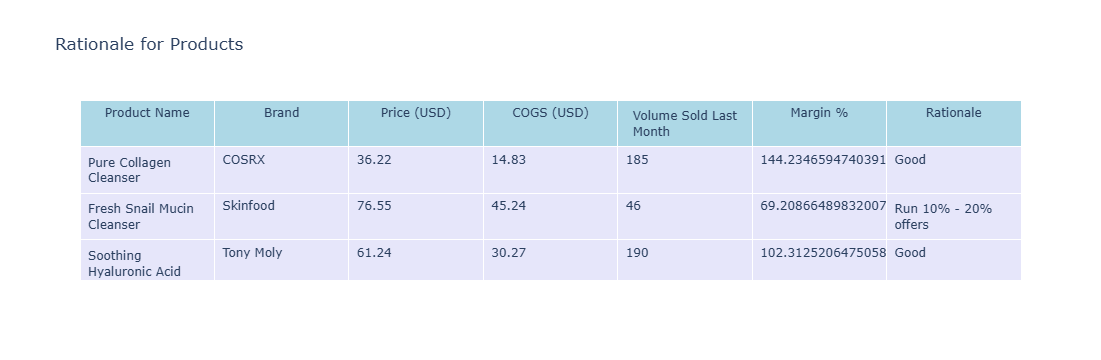

In [85]:
cols_to_show = ['Product Name', 'Brand', 'Price (USD)', 'COGS (USD)', 'Volume Sold Last Month','Margin %', 'Rationale']

fig = go.Figure(data=[go.Table(
    header=dict(values=cols_to_show, fill_color='lightblue', align='center'),
    cells=dict(values=[data[col] for col in cols_to_show], fill_color='lavender', align='left'))
])
fig.update_layout(title='Rationale for Products')
fig.show()